In [ ]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
sys.path.append('..')

import utilities.functions as functions
import utilities.descritiva as descritiva

from utilities.descritiva import  (
    matriz_migracao,
    cria_base_decil_wide
)

from utilities.functions import (
    summary,
    gerar_resumo_decis,
    resumo_coorte_ativa

)
from pathlib import Path
BASE_PATH = Path("/Users/maceli/ifood_cs/dados") 


In [ ]:
df_pub_u = pd.read_parquet(BASE_PATH / "gold" / "df_pub_un.parquet")

In [ ]:
df_pub_u.head()

Sumarizacao na visao cliente - mes

In [ ]:
summary(df_pub_u)

Clientes mes x target

 Matriz de migracao - cliente

In [ ]:
matriz_migracao(df_pub_u,mes_0=12,mes_1=1)

Dado o montante de clientes novos em janeiro a analise sera feita basead em cliente ambos os meses e cliente somente em janeiro

In [ ]:
id_both_monht=df_pub_u[df_pub_u['order_created_month']==12]['customer_id'].unique()
publico_janeiro_dezembro = df_pub_u[df_pub_u['customer_id'].isin(id_both_monht)].reset_index(drop=True)
publico_janeiro = df_pub_u[~df_pub_u['customer_id'].isin(id_both_monht)].reset_index(drop=True)

In [ ]:
publico_janeiro_dezembro.to_parquet(BASE_PATH / "gold" / "publico_janeiro_dezembro.parquet", index=False)

Pedidos por mes - target

In [ ]:
pedidos_total = (
    publico_janeiro_dezembro.groupby(['is_target','order_created_month'])['num_pedidos_mes']
      .sum()
      .reset_index(name='numero_de_pedidos_total')
)

pedidos_total['pct_mes'] = pedidos_total.groupby('order_created_month')['numero_de_pedidos_total'] \
                 .transform(lambda x: x / x.sum() * 100).round(2)

pedidos_total


Distruibuicao do total amount por mes

In [ ]:
df_stats_mes = publico_janeiro_dezembro.groupby(['order_created_month', 'is_target'])['total_amount_mes'].agg(
    Média=('mean'),
    Mediana=('median'),
    Mínimo=('min'),
    Máximo=('max'),
    Desvio_Padrão=('std')
).round(2)
df_stats_mes

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=publico_janeiro_dezembro,
    y='total_amount_mes',
    x='order_created_month',  
    hue='is_target'          
)
plt.title('Distribuição total amount menssal x  e  target')
plt.ylabel('Total Amount (R$)')
plt.xlabel('Mês')
plt.legend(title='Grupo')
plt.show()

Observa-se grande numero de outliers, verificar a distribuicao removendo outliers.

In [126]:
print(publico_janeiro_dezembro[publico_janeiro_dezembro['order_created_month']==12]['total_amount_mes'].describe().round(2))
print(publico_janeiro_dezembro[publico_janeiro_dezembro['order_created_month']==1]['total_amount_mes'].describe().round(2))



count     689.00
mean      102.40
std       127.75
min         8.50
25%        38.20
50%        63.00
75%       119.80
max      1595.80
Name: total_amount_mes, dtype: float64
count     689.00
mean      180.38
std       263.86
min         8.50
25%        51.60
50%       101.59
75%       202.00
max      4372.40
Name: total_amount_mes, dtype: float64


<Axes: >

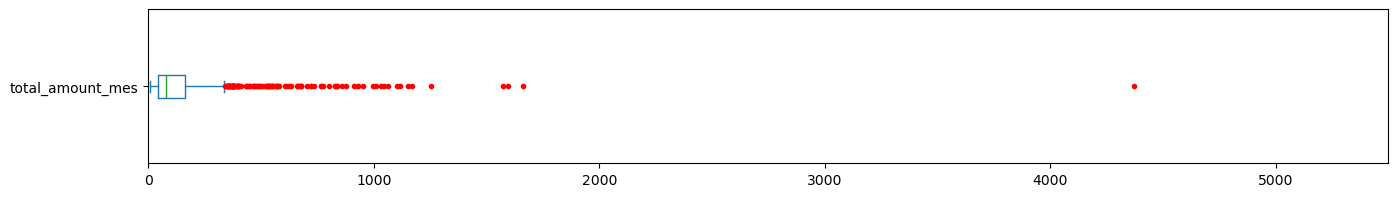

In [128]:
red_square = dict(markerfacecolor='r', markeredgecolor='r', marker='.')
publico_janeiro_dezembro['total_amount_mes'].plot(kind='box', xlim=(0, 5500), vert=False, flierprops=red_square, figsize=(16,2))

In [129]:
p75=np.nanpercentile(publico_janeiro_dezembro.loc[publico_janeiro_dezembro['order_created_month'] == 12, 'total_amount_mes' ],75)
p25=np.nanpercentile(publico_janeiro_dezembro.loc[publico_janeiro_dezembro['order_created_month'] == 12, 'total_amount_mes' ],25)

In [131]:
distance = 1.5 * (p75 - p25)
lim_sup= p75+distance
lim_inf = p25-distance
print(lim_sup)


242.2


Marcacao de outliers - amount na base historica e griando uma base somente com outliers

In [133]:
publico_janeiro_dezembro['outlier'] = publico_janeiro_dezembro['total_amount_mes'] > lim_sup
df_out= publico_janeiro_dezembro[publico_janeiro_dezembro['total_amount_mes'] > lim_sup]

In [135]:
total_amount = publico_janeiro_dezembro.groupby(['order_created_month', 'is_target']).agg(
    total_amount=('total_amount_mes', 'sum'),
    total_pedidos=('num_pedidos_mes', 'sum')
).round(2)
#total_amount

In [137]:
total_amount_out = df_out.groupby(['order_created_month', 'is_target']).agg(
    total_amount=('total_amount_mes', 'sum'),
    total_pedidos=('num_pedidos_mes', 'sum')
).round(2)
#total_amount_out

In [138]:
merged = (
    total_amount
    .merge(total_amount_out, on=['order_created_month', 'is_target'], how='left', suffixes=('_all', '_out'))
    .assign(
        pct_amount_out=lambda x: (x['total_amount_out'] / x['total_amount_all']).round(4),
        pct_pedidos_out=lambda x: (x['total_pedidos_out'] / x['total_pedidos_all']).round(4)
    )
)
merged

total_amount_all  total_pedidos_all  \
order_created_month is_target                                        
1                   control            49837.29               1125   
                    target             74447.21               1534   
12                  control            30441.24                662   
                    target             40109.21                862   

                               total_amount_out  total_pedidos_out  \
order_created_month is_target                                        
1                   control            27517.30                544   
                    target             46367.86                818   
12                  control             9826.69                166   
                    target             13795.16                228   

                               pct_amount_out  pct_pedidos_out  
order_created_month is_target                                   
1                   control            0.5521           0.4836  
                    target             0.6228           0.5332  
12                  control            0.3228           0.2508  
                    target             0.3439           0.2645

Migracao based in marcacao de outlier

In [139]:
matriz_migracao(publico_janeiro_dezembro, 12, 1, group_by_extra='outlier')

,mes_12,mes_1,is_target,outlier,total_clientes
0,0,1,control,True,33
1,0,1,target,True,51
2,1,0,control,False,33
3,1,0,target,False,51
4,1,1,control,False,252
5,1,1,control,True,25
6,1,1,target,False,296
7,1,1,target,True,32


Entender quem sao esse clientes outliers

In [140]:
df_out

,customer_id,is_target,order_created_month,num_pedidos_mes,num_pedidos_hist,total_amount_mes,ticket_medio,pedidos_sum,outlier,decil
7,009e7e2735e8312bf5a0f36229bb50f05c7f5d472c1eb8...,control,1,6,8,290.00,48.333333,6,True,10
11,01483e7c19f13070eb5088082b62c58d105182f24df27a...,target,1,3,4,313.90,104.633333,3,True,10
19,01b7a6b43d5d4b0d776e1438bf826dbc5ed6363b1f9001...,target,1,3,5,322.80,107.600000,3,True,10
23,01de36174a9e2784bec9f1fcfc2c8a5be869d325d78745...,control,1,12,16,348.40,29.033333,10+,True,10
29,0249f79364e9df0550782f2881f22733503f676f4029fb...,target,1,5,8,376.91,75.382000,5,True,10
...,...,...,...,...,...,...,...,...,...,...
1329,f73a361e699d9021f56ec2e4c03c46029711fd6842c6d1...,target,1,5,7,302.40,60.480000,5,True,10
1339,f9aca9a4893a2b92d9c5caa8d65bc274f98e83ce8f5177...,control,1,4,6,273.90,68.475000,4,True,10
1364,fea974555965ce9ab28c0738d6751ee9cf73a129fa5df7...,control,12,8,24,436.50,54.562500,8,True,10
1365,fea974555965ce9ab28c0738d6751ee9cf73a129fa5df7...,control,1,16,24,877.10,54.818750,10+,True,10


In [141]:
decil_dict = cria_base_decil_wide(publico_janeiro_dezembro, mes_0=12)

# 2) Aplicar
publico_janeiro_dezembro['decil'] = publico_janeiro_dezembro['total_amount_mes'].apply(
    lambda x: max([decil for decil, (min_val, max_val) in decil_dict.items() if x >= min_val])
)

Decil dict criado:
decil 1: 8.5 a 24.008000000000003
decil 2: 24.008000000000003 a 32.96
decil 3: 32.96 a 41.940000000000005
decil 4: 41.940000000000005 a 51.452
decil 5: 51.452 a 63.0
decil 6: 63.0 a 76.82000000000004
decil 7: 76.82000000000004 a 101.57400000000001
decil 8: 101.57400000000001 a 147.26
decil 9: 147.26 a 209.16000000000005
decil 10: 209.16000000000005 a 1595.8


In [142]:
clientes_mes = (
    publico_janeiro_dezembro.groupby(['decil'], dropna=False)
              ['customer_id']
              .nunique()
              .reset_index(name='numero_clientes_distintos')
)
clientes_mes

,decil,numero_clientes_distintos
0,1,69
1,2,72
2,3,74
3,4,70
4,5,77
5,6,91
6,7,101
7,8,127
8,9,133
9,10,168


In [115]:
publico_janeiro_dezembro

,customer_id,is_target,order_created_month,num_pedidos_mes,num_pedidos_hist,total_amount_mes,ticket_medio,pedidos_sum,outlier,decil
0,0005872d7c065b1b8afa4c4d8fbef264f992caa1022fd9...,target,12,3,8,68.9,22.966667,3,False,6
1,0005872d7c065b1b8afa4c4d8fbef264f992caa1022fd9...,target,1,5,8,139.2,27.840000,5,False,8
2,005f54ebf0a9afaaa6189281dc7f4e335ce71334cc63b5...,control,12,2,6,143.8,71.900000,2,False,8
3,005f54ebf0a9afaaa6189281dc7f4e335ce71334cc63b5...,control,1,4,6,199.3,49.825000,4,False,9
4,00624553890445cb4de900638fecde5911eed39457e652...,control,12,2,4,73.8,36.900000,2,False,6
...,...,...,...,...,...,...,...,...,...,...
1373,ff95d6cdc3e16926d9724218d27af3080ec76d7d7f526d...,control,1,3,5,94.9,31.633333,3,False,7
1374,fff94f356582d0639bed0fe53df8bc7d04dc7a163b6915...,target,12,1,2,23.2,23.200000,1,False,1
1375,fff94f356582d0639bed0fe53df8bc7d04dc7a163b6915...,target,1,1,2,23.2,23.200000,1,False,1
1376,fffb2563cae68ab46bdba19d24d1982c3e78fda9a350e4...,target,12,1,5,49.9,49.900000,1,False,4


In [143]:
def calcular_stats(group):
    media = group['total_amount_mes'].mean()
    std = group['total_amount_mes'].std()
    return pd.Series({
        'Total_Clientes': group['customer_id'].nunique(),
        'Total_Orders': group['num_pedidos_mes'].sum(),  # ou count() dependendo da sua estrutura
        'Média_Amount': media,
        'Mediana_Amount': group['total_amount_mes'].median(),
        'Mínimo_Amount': group['total_amount_mes'].min(),
        'Máximo_Amount': group['total_amount_mes'].max(),
        'Desvio_Padrão_Amount': std,
        'CV_Amount': (std / media * 100) if media != 0 else np.nan
    })

df_stats_mes = publico_janeiro_dezembro.groupby(['order_created_month', 'is_target','decil']).apply(calcular_stats).round(2)
#df_stats_mes

/var/folders/s5/dkrzm08d6wl79n0by4mcn72m0000gn/T/ipykernel_9544/2010098894.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_stats_mes = publico_janeiro_dezembro.groupby(['order_created_month', 'is_target','decil']).apply(calcular_stats).round(2)


In [ ]:
#publico_janeiro_dezembro.to_parquet(BASE_PATH / "gold" / "df_decil.parquet", index=False)

In [ ]:
os.makedirs('../../Resultados', exist_ok=True)

decil_summary.to_csv('../../Resultados/decil_summary.csv', index=False)



Numero de pedidos em Janeiro e Dezembro para o quem esteve em ambos meses

In [ ]:
publico_janeiro_dezembro

In [144]:

df_stats_mes = publico_janeiro_dezembro.groupby(['order_created_month', 'pedidos_sum']).agg(
    total_clientes=('customer_id', 'nunique')
).round(2)

df_stats_mes['pct_mes'] = df_stats_mes.groupby('order_created_month')['total_clientes'] \
                 .transform(lambda x: x / x.sum() * 100).round(2)


df_stats_hist = publico_janeiro_dezembro.groupby(['pedidos_sum']).agg(
    total_clientes=('customer_id', 'nunique')
).round(2)

df_stats_hist['pct_total'] = (df_stats_hist['total_clientes'] / df_stats_hist['total_clientes'].sum() * 100).round(2)

In [145]:
df_stats_hist

,total_clientes,pct_total
pedidos_sum,,
1,367,35.36
10,10,0.96
10+,48,4.62
2,209,20.13
3,143,13.78
4,97,9.34
5,51,4.91
6,44,4.24
7,33,3.18


In [ ]:
# Gráfico 1 - Total de clientes por mês e grupo
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)  # 1 linha, 2 colunas, posição 1
sns.barplot(
    data=df_stats_mes[df_stats_mes['order_created_month']==12],
    x='pedidos_sum',
    y='ticket_medio',
    hue='is_target'
)
plt.title('Número de Clientes por Mês')
plt.ylabel('Total de Clientes')
plt.xlabel('Mês')



In [ ]:
publico_janeiro_dezembro.head()

In [ ]:
publico_janeiro_dezembro

In [ ]:

pedidos_hist=resumo_coorte_ativa(publico_janeiro_dezembro,mes_coorte_inicio=12,mes_coorte_fim=1)
pedidos_hist

In [ ]:
pedidos_hist.to_csv('../../Resultados/pedidos_hist.csv', index=False)
df_stats_hist
df_stats_mes

In [ ]:
with pd.ExcelWriter('../../Resultados/analise_pedidos.xlsx') as writer:
    pedidos_hist.to_excel(writer, sheet_name='Pedidos_Hist', index=False)
    df_stats_hist.to_excel(writer, sheet_name='Stats_Hist', index=True)
    df_stats_mes.to_excel(writer, sheet_name='Stats_Mes', index=True)